In [1]:
import sys
import pandas as pd
import numpy as np

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("Libraries imported successfully!")

Python: c:\Users\Dell\AppData\Local\Programs\Python\Python310\python.exe
Pandas: 2.3.3
Libraries imported successfully!


In [2]:
df = pd.read_excel("../dataset/Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [3]:
print("Column Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


In [7]:
display(df.describe())

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
# Create a copy of the original dataset
sales_df = df.copy()

print("Original Shape:", sales_df.shape)

Original Shape: (541909, 8)


In [9]:
sales_df = sales_df.drop_duplicates()

print("After removing duplicates:", sales_df.shape)

After removing duplicates: (536641, 8)


In [10]:
sales_df = sales_df.dropna(subset=["Description"])

print("After removing missing Description:", sales_df.shape)

After removing missing Description: (535187, 8)


In [11]:
sales_df = sales_df.dropna(subset=["Description"])

print("After removing missing Description:", sales_df.shape)

After removing missing Description: (535187, 8)


In [12]:
sales_df = sales_df[sales_df["Quantity"] > 0]

print("After removing invalid Quantity:", sales_df.shape)

After removing invalid Quantity: (525462, 8)


In [13]:
sales_df = sales_df[sales_df["UnitPrice"] > 0]

print("After removing invalid UnitPrice:", sales_df.shape)

After removing invalid UnitPrice: (524878, 8)


In [14]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

print("Revenue column created successfully!")
display(sales_df.head())

Revenue column created successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
print("Final Dataset Shape:", sales_df.shape)

print("\nMissing Values:")
print(sales_df.isnull().sum())

print("\nDuplicate Rows:", sales_df.duplicated().sum())

Final Dataset Shape: (524878, 9)

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

Duplicate Rows: 0


In [16]:
# Sales Performance KPIs

total_revenue = sales_df["Revenue"].sum()
total_quantity = sales_df["Quantity"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
unique_products = sales_df["StockCode"].nunique()
unique_countries = sales_df["Country"].nunique()
unique_customers = sales_df["CustomerID"].nunique()

average_order_value = total_revenue / total_orders

print("========== SALES KPIs ==========")
print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Total Quantity     : {total_quantity:,}")
print(f"Total Orders       : {total_orders:,}")
print(f"Unique Products    : {unique_products:,}")
print(f"Unique Countries   : {unique_countries:,}")
print(f"Unique Customers   : {unique_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

========== SALES KPIs ==========
Total Revenue      : £10,642,110.80
Total Quantity     : 5,572,420
Total Orders       : 19,960
Unique Products    : 3,922
Unique Countries   : 38
Unique Customers   : 4,338
Average Order Value: £533.17


In [17]:
kpi_data = {
    "Metric": [
        "Total Revenue",
        "Total Quantity",
        "Total Orders",
        "Unique Products",
        "Unique Countries",
        "Unique Customers",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_orders,
        unique_products,
        unique_countries,
        unique_customers,
        average_order_value
    ]
}

kpi_df = pd.DataFrame(kpi_data)

display(kpi_df)

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Quantity,5.572420e+06
2,Total Orders,1.996000e+04
3,Unique Products,3.922000e+03
4,Unique Countries,3.800000e+01
5,Unique Customers,4.338000e+03
6,Average Order Value,5.331719e+02


In [18]:
# Create Year-Month column
sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

# Monthly revenue
monthly_revenue = (
    sales_df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

display(monthly_revenue)

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


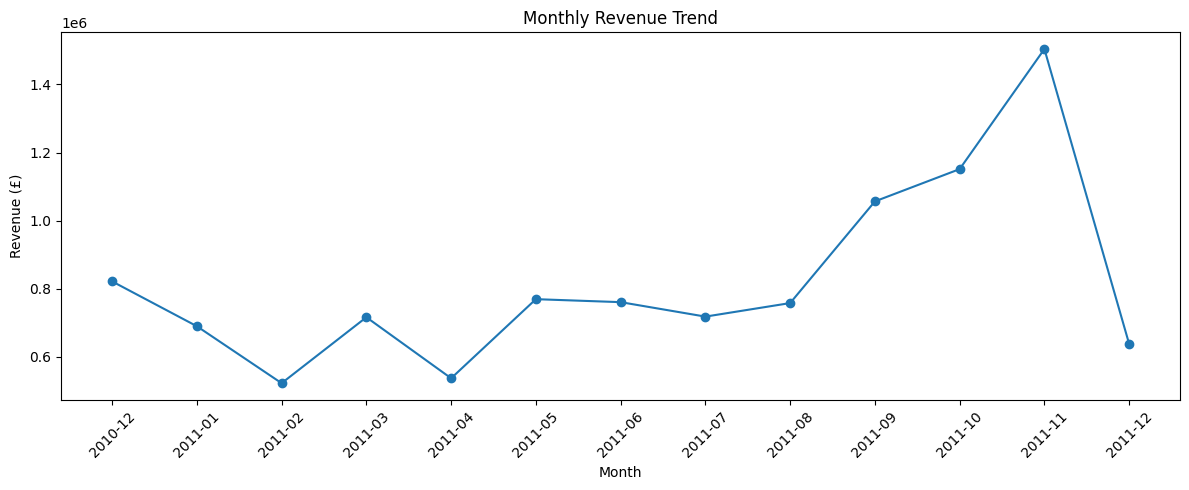

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [20]:
highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
YearMonth       2011-11
Revenue      1503866.78
Name: 11, dtype: object

Lowest Revenue Month:
YearMonth      2011-02
Revenue      522545.56
Name: 2, dtype: object


In [21]:
product_revenue = (
    sales_df.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

display(product_revenue.head(10))

,StockCode,Description,Revenue
4150,DOT,DOTCOM POSTAGE,206248.77
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
2669,47566,PARTY BUNTING,99445.23
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
4153,POST,POSTAGE,78101.88
4151,M,Manual,77750.27
1951,23084,RABBIT NIGHT LIGHT,66870.03


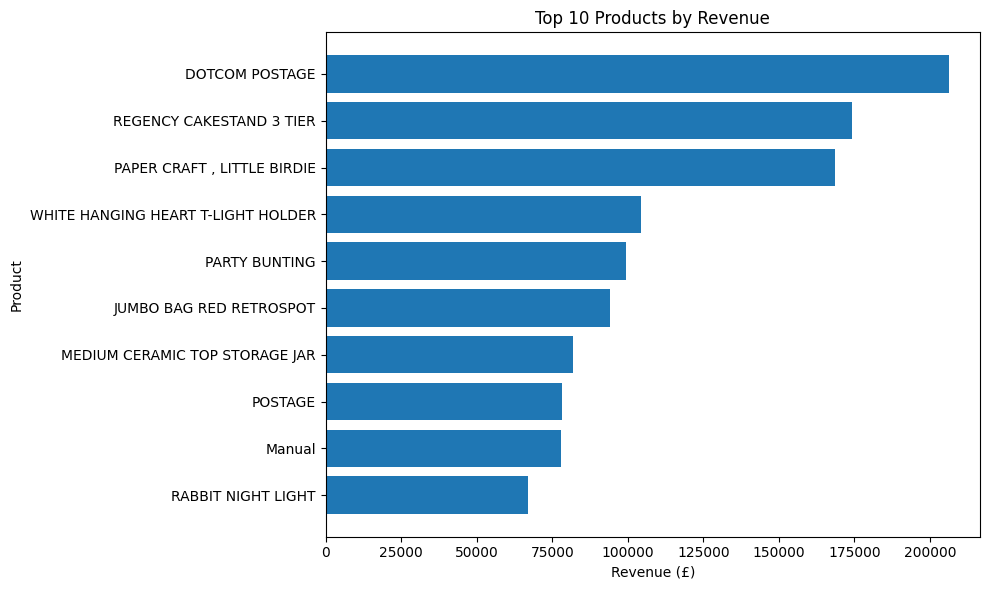

In [22]:
top_10_products = product_revenue.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products["Description"],
    top_10_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [23]:
product_quantity = (
    sales_df.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values("Quantity", ascending=False)
)

display(product_quantity.head(10))

,StockCode,Description,Quantity
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3761,85099B,JUMBO BAG RED RETROSPOT,48371
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580
1051,22197,POPCORN HOLDER,36749
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362
1951,23084,RABBIT NIGHT LIGHT,30739
1327,22492,MINI PAINT SET VINTAGE,26633


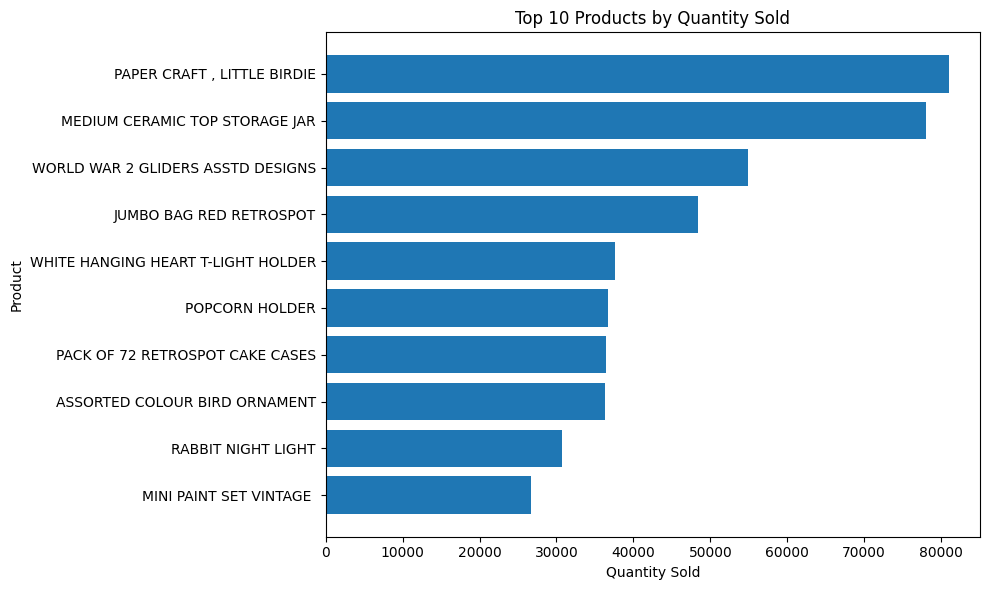

In [24]:
top_10_quantity = product_quantity.head(10).sort_values("Quantity")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_quantity["Description"],
    top_10_quantity["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [25]:
# Country-wise sales analysis

country_sales = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

display(country_sales.head(15))

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


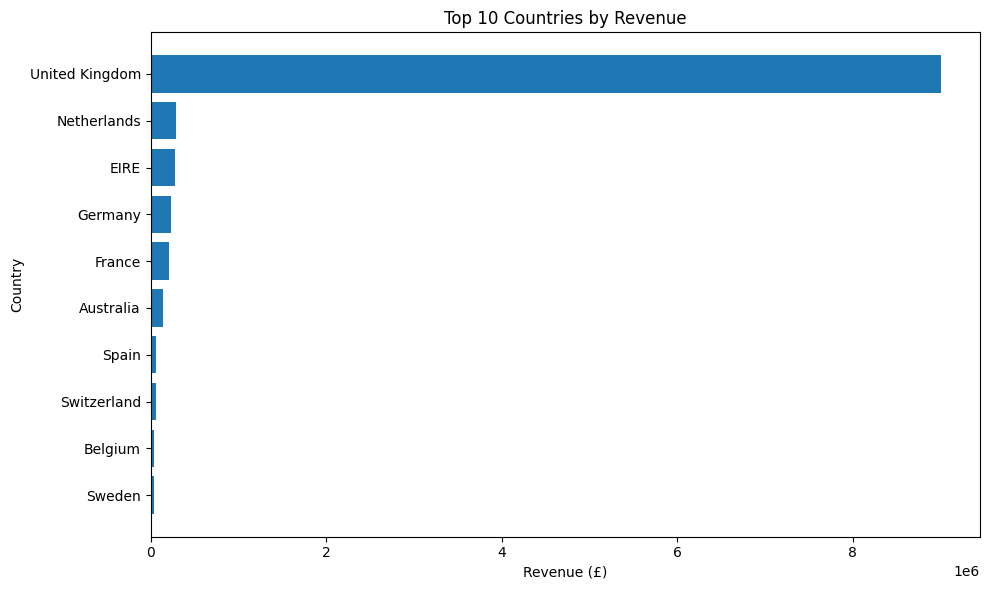

In [26]:
top_10_countries = country_sales.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries["Country"],
    top_10_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

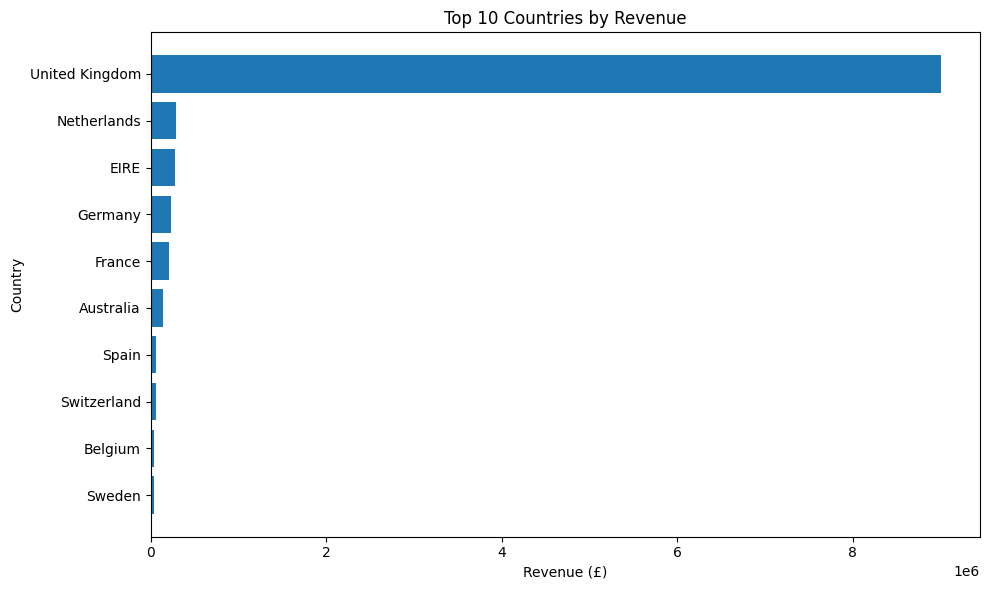

In [27]:
top_10_countries = country_sales.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries["Country"],
    top_10_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [28]:
country_orders = (
    sales_df.groupby("Country")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
)

country_orders.columns = ["Country", "Orders"]

display(country_orders.head(10))

,Country,Orders
36,United Kingdom,18019
14,Germany,457
13,France,392
10,EIRE,288
3,Belgium,98
24,Netherlands,94
31,Spain,90
27,Portugal,58
0,Australia,57
33,Switzerland,54


In [29]:
customer_revenue = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

display(customer_revenue.head(10))

,CustomerID,Revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17
55,12415.0,124914.53
1333,14156.0,117210.08
3771,17511.0,91062.38
2702,16029.0,80850.84
0,12346.0,77183.60


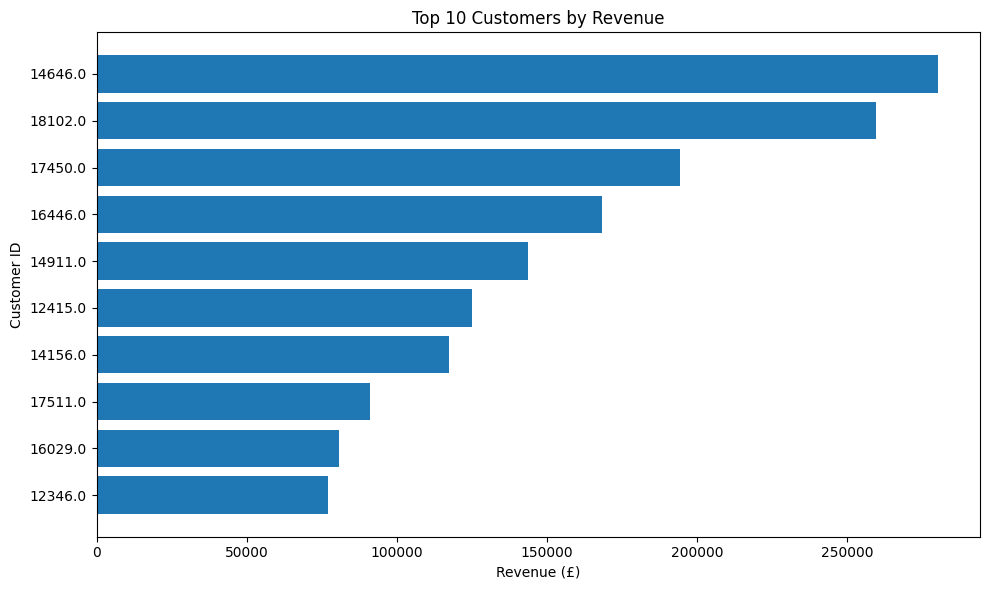

In [30]:
top_10_customers = customer_revenue.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers["CustomerID"].astype(str),
    top_10_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [31]:
customer_orders = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
)

customer_orders.columns = ["CustomerID", "Orders"]

display(customer_orders.head(10))

,CustomerID,Orders
326,12748.0,209
1879,14911.0,201
4010,17841.0,124
562,13089.0,97
1661,14606.0,93
2176,15311.0,91
481,12971.0,86
1689,14646.0,73
2702,16029.0,63
795,13408.0,62


In [32]:
customer_summary = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Total_Orders"]
)

display(customer_summary.head())

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
0,12346.0,77183.60,1,74215,77183.600000
1,12347.0,4310.00,7,2458,615.714286
2,12348.0,1797.24,4,2341,449.310000
3,12349.0,1757.55,1,631,1757.550000
4,12350.0,334.40,1,197,334.400000


In [33]:
print("========== BUSINESS INSIGHTS ==========\n")

# Highest revenue month
highest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]
print(
    f"Highest Revenue Month: {highest_month['YearMonth']} "
    f"with £{highest_month['Revenue']:,.2f}"
)

# Lowest revenue month
lowest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmin()]
print(
    f"Lowest Revenue Month: {lowest_month['YearMonth']} "
    f"with £{lowest_month['Revenue']:,.2f}"
)

# Top product
top_product = product_revenue.iloc[0]
print(
    f"\nTop Product by Revenue: {top_product['Description']} "
    f"with £{top_product['Revenue']:,.2f}"
)

# Top country
top_country = country_sales.iloc[0]
print(
    f"Top Country by Revenue: {top_country['Country']} "
    f"with £{top_country['Revenue']:,.2f}"
)

# Top customer
top_customer = customer_revenue.iloc[0]
print(
    f"Top Customer by Revenue: {int(top_customer['CustomerID'])} "
    f"with £{top_customer['Revenue']:,.2f}"
)

========== BUSINESS INSIGHTS ==========

Highest Revenue Month: 2011-11 with £1,503,866.78
Lowest Revenue Month: 2011-02 with £522,545.56

Top Product by Revenue: DOTCOM POSTAGE with £206,248.77
Top Country by Revenue: United Kingdom with £9,001,744.09
Top Customer by Revenue: 14646 with £280,206.02


In [34]:
print("========== FINAL DATASET SUMMARY ==========")

print(f"Total Transactions : {len(sales_df):,}")
print(f"Total Revenue      : £{sales_df['Revenue'].sum():,.2f}")
print(f"Total Quantity     : {sales_df['Quantity'].sum():,}")
print(f"Total Orders       : {sales_df['InvoiceNo'].nunique():,}")
print(f"Unique Products    : {sales_df['StockCode'].nunique():,}")
print(f"Unique Countries   : {sales_df['Country'].nunique():,}")
print(f"Unique Customers   : {sales_df['CustomerID'].nunique():,}")

========== FINAL DATASET SUMMARY ==========
Total Transactions : 524,878
Total Revenue      : £10,642,110.80
Total Quantity     : 5,572,420
Total Orders       : 19,960
Unique Products    : 3,922
Unique Countries   : 38
Unique Customers   : 4,338


In [35]:
sales_df.to_csv(
    "../dataset/cleaned_sales_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
